# BCE Logistic Regression — Thực nghiệm tối ưu hóa (bản logic, rút gọn)

Notebook này chỉ giữ **một câu chuyện chính**:

1. Xác định bài toán tối ưu của Logistic Regression + BCE.
2. Kiểm tra gradient/Hessian và geometry cơ bản.
3. Chuẩn bị 4 optimizer: **GD, NAG, SGD, Newton**.
4. So sánh **một lần duy nhất** bằng một bảng tổng hợp.
5. Giữ optimizer tốt nhất, sau đó mới thử **L2 regularization**.
6. Chọn $\lambda$ và threshold trên validation, rồi đánh giá test đúng một lần.

Các phân tích phụ như Newton + backtracking và GD + L2 được chuyển xuống **Appendix** để không làm đứt mạch chính.

> Quy ước công thức trong notebook: chỉ dùng `$...$` và `$$...$$` để tránh lỗi hiển thị Markdown.


## 0. Bài toán đang tối ưu cái gì?

Mỗi mẫu $i$ có vector đặc trưng $x_i\in\mathbb{R}^{21}$ và nhãn $y_i\in\{0,1\}$.

Logistic Regression tính linear score:

$$
z_i=x_i^T w+b=\sum_{j=1}^{21}x_{ij}w_j+b.
$$

Trong đó:

- $x_i$: dữ liệu đã biết.
- $y_i$: nhãn thật đã biết.
- $w=(w_1,\dots,w_{21})$: 21 trọng số cần học.
- $b$: bias cần học.
- $\theta=[w,b]$: vector gom toàn bộ 22 tham số cần tối ưu.

Từ $z_i$, xác suất dự đoán là:

$$
p_i=\sigma(z_i)=\frac{1}{1+e^{-z_i}}.
$$

BCE quen thuộc:

$$
F(\theta)=-\frac{1}{n}\sum_{i=1}^{n}\left[y_i\log p_i+(1-y_i)\log(1-p_i)\right].
$$

Bài toán tối ưu là:

$$
\min_{\theta}F(\theta)\quad\Longleftrightarrow\quad\min_{w,b}F(w,b).
$$

Trong code, BCE được viết ở dạng tương đương nhưng ổn định số hơn:

$$
F(\theta)=\frac{1}{n}\sum_{i=1}^{n}\left[\log(1+e^{z_i})-y_i z_i\right].
$$

Hai công thức là **cùng một BCE**. Dạng thứ hai giúp tránh overflow/underflow khi $|z_i|$ rất lớn.


In [1]:
from pathlib import Path
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
)

SEED = 42
TARGET_COL = "Diabetes_binary"

# False = chạy chính thức; True = kiểm tra nhanh notebook.
FAST_MODE = False

GD_MAX_ITERS = 120 if FAST_MODE else 500
NAG_MAX_ITERS = 120 if FAST_MODE else 500
NEWTON_MAX_ITERS = 12 if FAST_MODE else 30
SGD_TUNE_EPOCHS = 5 if FAST_MODE else 20
SGD_MAX_EPOCHS = 50 if FAST_MODE else 500
BATCH_SIZE = 512
GRAD_TOL = 1e-5
SGD_DECAY = 0.05

OUTPUT_DIR = Path("./bce_experiment_outputs_clean")
OUTPUT_DIR.mkdir(exist_ok=True)

CANDIDATE_DATA_DIRS = [
    Path("./data/processed"),
    Path("./upload"),
    Path("."),
]

def resolve_csv(filename):
    for folder in CANDIDATE_DATA_DIRS:
        path = folder / filename
        if path.exists():
            return path
    searched = "\n".join(str(d / filename) for d in CANDIDATE_DATA_DIRS)
    raise FileNotFoundError(
        f"Không tìm thấy {filename}. Đã thử:\n{searched}\n"
        "Hãy đặt train.csv, val.csv, test.csv vào một trong các thư mục trên."
    )

TRAIN_PATH = resolve_csv("train.csv")
VAL_PATH = resolve_csv("val.csv")

print("TRAIN:", TRAIN_PATH)
print("VAL  :", VAL_PATH)
print("FAST_MODE =", FAST_MODE)


TRAIN: data/processed/train.csv
VAL  : data/processed/val.csv
FAST_MODE = False


## 1. Đọc frozen train/validation split

Notebook **không preprocessing lại dữ liệu**. Nó dùng trực tiếp `train.csv` và `val.csv` đã được nhóm cố định trước đó.

Mục đích của cell này chỉ là kiểm tra:

- số mẫu,
- số feature,
- thứ tự feature,
- tỷ lệ lớp dương.


In [2]:
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)

if TARGET_COL not in train_df.columns or TARGET_COL not in val_df.columns:
    raise ValueError(f"Thiếu target column: {TARGET_COL}")

feature_cols = [c for c in train_df.columns if c != TARGET_COL]
val_feature_cols = [c for c in val_df.columns if c != TARGET_COL]

if feature_cols != val_feature_cols:
    raise ValueError("Feature schema/order của train và validation không giống nhau.")

X_train = train_df[feature_cols].to_numpy(dtype=np.float64)
y_train = train_df[TARGET_COL].to_numpy(dtype=np.float64)
X_val = val_df[feature_cols].to_numpy(dtype=np.float64)
y_val = val_df[TARGET_COL].to_numpy(dtype=np.float64)

def class_summary(y):
    n_pos = int(np.sum(y == 1))
    n_neg = int(np.sum(y == 0))
    return {
        "n": len(y),
        "n_pos": n_pos,
        "n_neg": n_neg,
        "pos_ratio": n_pos / len(y),
    }

data_summary = pd.DataFrame(
    [class_summary(y_train), class_summary(y_val)],
    index=["train", "validation"],
)

print("Số feature:", len(feature_cols))
print("Features:", feature_cols)
display(data_summary)


Số feature: 21
Features: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


,n,n_pos,n_neg,pos_ratio
train,660377,107366,553011,0.162583
validation,110599,16693,93906,0.150933


## 2. BCE, gradient và Hessian

Gradient là vector đạo hàm theo **toàn bộ 22 tham số**:

$$
\nabla F(\theta)=
\begin{bmatrix}
\partial F/\partial w_1\\
\vdots\\
\partial F/\partial w_{21}\\
\partial F/\partial b
\end{bmatrix}.
$$

Với BCE Logistic Regression:

$$
\nabla_w F=\frac{1}{n}X^T(p-y),
\qquad
\frac{\partial F}{\partial b}=\frac{1}{n}\sum_i(p_i-y_i).
$$

Hessian $H(\theta)$ chứa đạo hàm bậc hai và mô tả curvature. Với Logistic Regression, phần curvature có hệ số:

$$
p_i(1-p_i)\ge 0,
$$

nên Hessian là positive semidefinite và BCE là convex.

### Numerical stability

Code không tính trực tiếp mọi biểu thức theo đúng hình thức trên giấy. Ví dụ với $z=-1000$, tính $e^{-z}=e^{1000}$ có thể overflow. Vì vậy sigmoid được tách theo dấu của $z$, và BCE dùng `np.logaddexp(0, z)`. Công thức toán học **không thay đổi**, chỉ cách tính trên máy ổn định hơn.


In [3]:
def sigmoid(z):
    z = np.asarray(z, dtype=np.float64)
    out = np.empty_like(z)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[~pos])
    out[~pos] = ez / (1.0 + ez)
    return out


def bce_objective_grad(theta, X, y, l2=0.0):
    """Mean BCE + 0.5*l2*||w||^2; bias không regularize."""
    w = theta[:-1]
    b = theta[-1]
    z = X @ w + b

    data_loss = np.mean(np.logaddexp(0.0, z) - y * z)
    objective = data_loss + 0.5 * l2 * np.dot(w, w)

    p = sigmoid(z)
    r = p - y
    grad_w = (X.T @ r) / len(y) + l2 * w
    grad_b = np.mean(r)
    grad = np.r_[grad_w, grad_b]

    return float(objective), grad


def bce_hessian(theta, X, y, l2=0.0):
    w = theta[:-1]
    b = theta[-1]
    p = sigmoid(X @ w + b)
    dvec = p * (1.0 - p)
    n, d = X.shape

    H = np.empty((d + 1, d + 1), dtype=np.float64)
    H[:-1, :-1] = (X.T @ (dvec[:, None] * X)) / n + l2 * np.eye(d)

    cross = (X.T @ dvec) / n
    H[:-1, -1] = cross
    H[-1, :-1] = cross
    H[-1, -1] = np.mean(dvec)
    return H


def global_hessian_upper_bound(X, l2=0.0):
    """Global Hessian upper bound: H(theta) <= (1/4n) A^T A + lambda R."""
    n, d = X.shape
    gram = np.empty((d + 1, d + 1), dtype=np.float64)
    gram[:-1, :-1] = (X.T @ X) / n
    mean_x = X.mean(axis=0)
    gram[:-1, -1] = mean_x
    gram[-1, :-1] = mean_x
    gram[-1, -1] = 1.0

    R = np.diag(np.r_[np.ones(d), 0.0])
    return 0.25 * gram + l2 * R


def condition_number_from_eigs(eigs, eps=1e-12):
    positive = eigs[eigs > eps]
    if len(positive) == 0:
        return np.inf
    return float(positive.max() / positive.min())


## 3. Kiểm tra code và geometry ban đầu

Có hai việc cần kiểm tra trước khi so optimizer:

1. Gradient/Hessian giải tích có khớp finite difference không?
2. Objective có ill-conditioned không?

Tại $\theta_0=0$, ta quan tâm:

$$
\lambda_{\min}(H),\quad \lambda_{\max}(H),\quad
\kappa=\frac{\lambda_{\max}}{\lambda_{\min}}.
$$

Ngoài ra, vì $p_i(1-p_i)\le 1/4$, ta có global Lipschitz upper bound $L$ cho gradient. Từ đó $1/L$ là một **step-size scale có cơ sở lý thuyết** cho GD; nó không nhất thiết là step tốt nhất trong thực nghiệm.


In [4]:
# Numerical gradient/Hessian check trên subset nhỏ.
rng = np.random.default_rng(SEED)
check_n = min(2000, len(y_train))
check_idx = rng.choice(len(y_train), size=check_n, replace=False)
X_check = X_train[check_idx]
y_check = y_train[check_idx]

theta_check = rng.normal(scale=0.05, size=X_train.shape[1] + 1)
_, g_analytic = bce_objective_grad(theta_check, X_check, y_check)
H_analytic = bce_hessian(theta_check, X_check, y_check)

eps = 1e-5
g_numeric = np.zeros_like(theta_check)
for j in range(len(theta_check)):
    e = np.zeros_like(theta_check)
    e[j] = eps
    fp, _ = bce_objective_grad(theta_check + e, X_check, y_check)
    fm, _ = bce_objective_grad(theta_check - e, X_check, y_check)
    g_numeric[j] = (fp - fm) / (2 * eps)

H_numeric = np.zeros_like(H_analytic)
for j in range(len(theta_check)):
    e = np.zeros_like(theta_check)
    e[j] = eps
    _, gp = bce_objective_grad(theta_check + e, X_check, y_check)
    _, gm = bce_objective_grad(theta_check - e, X_check, y_check)
    H_numeric[:, j] = (gp - gm) / (2 * eps)

foundation_check = pd.Series({
    "gradient_max_abs_error": np.max(np.abs(g_analytic - g_numeric)),
    "hessian_max_abs_error": np.max(np.abs(H_analytic - H_numeric)),
    "hessian_symmetry_error": np.max(np.abs(H_analytic - H_analytic.T)),
    "hessian_min_eigenvalue_check_subset": np.linalg.eigvalsh(H_analytic)[0],
})

theta0 = np.zeros(X_train.shape[1] + 1)
H0 = bce_hessian(theta0, X_train, y_train)
eig0 = np.linalg.eigvalsh(H0)

H_upper = global_hessian_upper_bound(X_train)
L_global = float(np.linalg.eigvalsh(H_upper)[-1])
eta_theory = 1.0 / L_global

geometry_initial = pd.Series({
    "lambda_min_H(theta0)": eig0[0],
    "lambda_max_H(theta0)": eig0[-1],
    "condition_number_H(theta0)": condition_number_from_eigs(eig0),
    "global_L_upper_bound": L_global,
    "1/L": eta_theory,
})

print("Numerical checks:")
display(foundation_check)
print("Geometry tại theta=0:")
display(geometry_initial)


Numerical checks:


gradient_max_abs_error                 7.018559e-10
hessian_max_abs_error                  1.178298e-08
hessian_symmetry_error                 1.776357e-15
hessian_min_eigenvalue_check_subset    2.620542e-03
dtype: float64

Geometry tại theta=0:


lambda_min_H(theta0)              0.002727
lambda_max_H(theta0)             35.282567
condition_number_H(theta0)    12937.404773
global_L_upper_bound             35.282567
1/L                               0.028343
dtype: float64

# Stage 1 — GD: step size có ảnh hưởng thật không?

Đây là thí nghiệm riêng cho GD, nhằm trả lời một câu hỏi duy nhất:

> Nếu giữ nguyên BCE và GD, thay step size thì tốc độ giảm objective thay đổi thế nào?

Ta thử fixed step $0.5/L$, $1/L$, $1.5/L$, $1.9/L$ và Armijo backtracking.

Armijo không phải optimizer thứ năm; nó chỉ là **cách chọn step cho GD**.


In [5]:
def make_record(name, iteration, unit, theta, X, y, Xv, yv, start_time,
                l2=0.0, step_size=np.nan):
    f, g = bce_objective_grad(theta, X, y, l2=l2)
    # Validation luôn đo BCE thuần, không cộng penalty.
    fv, _ = bce_objective_grad(theta, Xv, yv, l2=0.0)
    return {
        "optimizer": name,
        "iteration": int(iteration),
        "unit": unit,
        "train_objective": float(f),
        "validation_bce": float(fv),
        "gradient_norm": float(np.linalg.norm(g)),
        "step_size": float(step_size) if np.isfinite(step_size) else np.nan,
        "wall_time_seconds": float(time.perf_counter() - start_time),
    }


def gd_fixed(X, y, Xv, yv, lr, max_iter=500, tol=1e-5, l2=0.0, name=None):
    theta = np.zeros(X.shape[1] + 1)
    hist = []
    start = time.perf_counter()
    name = name or f"GD fixed lr={lr:.6g}"

    hist.append(make_record(name, 0, "iteration", theta, X, y, Xv, yv, start,
                            l2=l2, step_size=0.0))

    for k in range(1, max_iter + 1):
        _, g = bce_objective_grad(theta, X, y, l2=l2)
        theta = theta - lr * g

        row = make_record(name, k, "iteration", theta, X, y, Xv, yv, start,
                          l2=l2, step_size=lr)
        hist.append(row)

        if not np.isfinite(row["train_objective"]):
            break
        if row["gradient_norm"] <= tol:
            break

    return theta, pd.DataFrame(hist)


def gd_backtracking(X, y, Xv, yv, max_iter=500, tol=1e-5,
                    l2=0.0, alpha0=1.0, rho=0.5, c=1e-4):
    theta = np.zeros(X.shape[1] + 1)
    hist = []
    start = time.perf_counter()
    previous_step = alpha0
    name = "GD + Armijo"

    hist.append(make_record(name, 0, "iteration", theta, X, y, Xv, yv, start,
                            l2=l2, step_size=0.0))

    for k in range(1, max_iter + 1):
        f, g = bce_objective_grad(theta, X, y, l2=l2)
        gg = np.dot(g, g)
        step = min(previous_step / rho, alpha0)

        for _ in range(60):
            candidate = theta - step * g
            fc, _ = bce_objective_grad(candidate, X, y, l2=l2)
            if fc <= f - c * step * gg:
                break
            step *= rho
        else:
            raise RuntimeError("Armijo line search không tìm được step hợp lệ.")

        theta = candidate
        previous_step = step

        row = make_record(name, k, "iteration", theta, X, y, Xv, yv, start,
                          l2=l2, step_size=step)
        hist.append(row)

        if row["gradient_norm"] <= tol:
            break

    return theta, pd.DataFrame(hist)


In [6]:
gd_runs = {}
gd_models = {}

for factor in [0.5, 1.0, 1.5, 1.9]:
    lr = factor * eta_theory
    name = f"GD {factor:.1f}/L"
    theta, hist = gd_fixed(
        X_train, y_train, X_val, y_val,
        lr=lr,
        max_iter=GD_MAX_ITERS,
        tol=GRAD_TOL,
        name=name,
    )
    gd_runs[name] = hist
    gd_models[name] = theta

theta_armijo, hist_armijo = gd_backtracking(
    X_train, y_train, X_val, y_val,
    max_iter=GD_MAX_ITERS,
    tol=GRAD_TOL,
)
gd_runs["GD + Armijo"] = hist_armijo
gd_models["GD + Armijo"] = theta_armijo

gd_summary = pd.DataFrame([
    {
        "configuration": name,
        "iterations": int(hist.iloc[-1]["iteration"]),
        "train_objective": hist.iloc[-1]["train_objective"],
        "validation_bce": hist.iloc[-1]["validation_bce"],
        "gradient_norm": hist.iloc[-1]["gradient_norm"],
        "converged": bool(hist.iloc[-1]["gradient_norm"] <= GRAD_TOL),
        "last_step": hist.iloc[-1]["step_size"],
        "wall_time_seconds": hist.iloc[-1]["wall_time_seconds"],
    }
    for name, hist in gd_runs.items()
]).sort_values("train_objective")

best_gd_name = str(gd_summary.iloc[0]["configuration"])
best_gd_hist = gd_runs[best_gd_name]
best_gd_theta = gd_models[best_gd_name]

display(gd_summary)
print("Representative GD:", best_gd_name)


,configuration,iterations,train_objective,validation_bce,gradient_norm,converged,last_step,wall_time_seconds
4,GD + Armijo,500,0.376969,0.357789,0.010634,False,0.125000,156.060591
3,GD 1.9/L,500,0.383379,0.363831,0.017175,False,0.053851,73.069874
2,GD 1.5/L,500,0.385299,0.365647,0.019736,False,0.042514,72.530828
1,GD 1.0/L,500,0.388796,0.368913,0.025268,False,0.028343,94.644984
0,GD 0.5/L,500,0.396038,0.375501,0.041336,False,0.014171,83.548380


Representative GD: GD + Armijo


### Biểu đồ chính duy nhất cho thí nghiệm GD

Biểu đồ này chỉ trả lời: **step size nào làm BCE giảm nhanh hơn theo iteration?**

Gradient norm và trạng thái hội tụ đã có trong bảng trên nên không vẽ thêm một biểu đồ riêng.


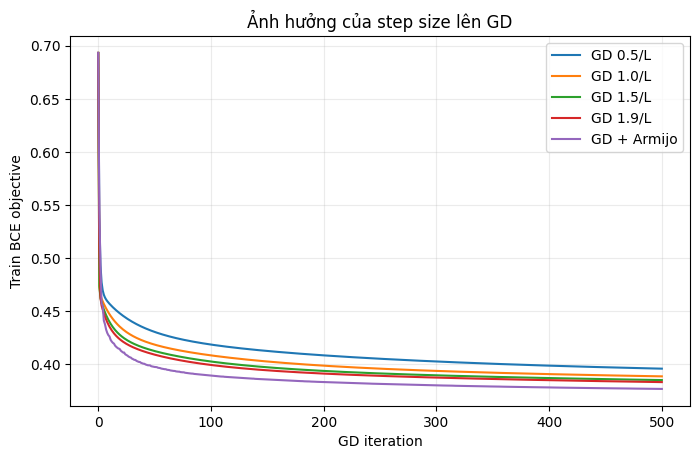

In [7]:
plt.figure(figsize=(8, 4.8))
for name, hist in gd_runs.items():
    plt.plot(hist["iteration"], hist["train_objective"], label=name)

plt.xlabel("GD iteration")
plt.ylabel("Train BCE objective")
plt.title("Ảnh hưởng của step size lên GD")
plt.grid(alpha=0.25)
plt.legend()
plt.show()


# Stage 2 — Chuẩn bị NAG, SGD và Newton

Mục tiêu của Stage 2 **chưa phải chọn optimizer**. Ta chỉ chuẩn bị một cấu hình đại diện hợp lý cho từng họ thuật toán.

- **NAG:** thử cùng scale step $1/L$ như GD, giữ $\beta=0.9$.
- **SGD:** tune initial learning rate bằng budget ngắn; sau đó so fixed LR với LR decay và dùng decay làm representative nếu nó giảm noise/stationarity tốt hơn.
- **Newton:** dùng **Plain Newton** trước, tức full Newton step $\alpha=1$, không damping, không line search.


In [8]:
def nesterov(X, y, Xv, yv, lr, beta=0.9, max_iter=500,
             tol=1e-5, l2=0.0, name=None):
    theta = np.zeros(X.shape[1] + 1)
    velocity = np.zeros_like(theta)
    hist = []
    start = time.perf_counter()
    name = name or f"NAG lr={lr:.6g}"

    hist.append(make_record(name, 0, "iteration", theta, X, y, Xv, yv, start,
                            l2=l2, step_size=0.0))

    for k in range(1, max_iter + 1):
        lookahead = theta + beta * velocity
        _, g = bce_objective_grad(lookahead, X, y, l2=l2)

        velocity = beta * velocity - lr * g
        theta = theta + velocity

        row = make_record(name, k, "iteration", theta, X, y, Xv, yv, start,
                          l2=l2, step_size=lr)
        hist.append(row)

        if not np.isfinite(row["train_objective"]):
            break
        if row["gradient_norm"] <= tol:
            break

    return theta, pd.DataFrame(hist)


nag_runs = {}
nag_models = {}

for factor in [0.5, 1.0, 1.5, 1.9]:
    lr = factor * eta_theory
    name = f"NAG {factor:.1f}/L"
    theta, hist = nesterov(
        X_train, y_train, X_val, y_val,
        lr=lr,
        beta=0.9,
        max_iter=NAG_MAX_ITERS,
        tol=GRAD_TOL,
        name=name,
    )
    nag_runs[name] = hist
    nag_models[name] = theta

nag_summary = pd.DataFrame([
    {
        "configuration": name,
        "iterations": int(hist.iloc[-1]["iteration"]),
        "train_objective": hist.iloc[-1]["train_objective"],
        "validation_bce": hist.iloc[-1]["validation_bce"],
        "gradient_norm": hist.iloc[-1]["gradient_norm"],
        "converged": bool(hist.iloc[-1]["gradient_norm"] <= GRAD_TOL),
    }
    for name, hist in nag_runs.items()
]).sort_values("train_objective")

best_nag_name = str(nag_summary.iloc[0]["configuration"])
best_nag_hist = nag_runs[best_nag_name]
best_nag_theta = nag_models[best_nag_name]

display(nag_summary)
print("Representative NAG:", best_nag_name)


,configuration,iterations,train_objective,validation_bce,gradient_norm,converged
3,NAG 1.9/L,500,0.369219,0.351253,0.004557,False
2,NAG 1.5/L,500,0.370534,0.352294,0.005118,False
1,NAG 1.0/L,500,0.372782,0.354133,0.006260,False
0,NAG 0.5/L,500,0.376703,0.357552,0.009132,False


Representative NAG: NAG 1.9/L


## 2.1 SGD: fixed learning rate và learning-rate decay

Mini-batch SGD dùng gradient của từng batch thay vì full gradient. Với fixed LR, thuật toán có thể vào vùng objective thấp nhanh nhưng tiếp tục dao động quanh nghiệm vì stochastic noise.

Ta dùng schedule:

$$
\eta_e=\frac{\eta_0}{1+\gamma(e-1)}.
$$

Decay không phải optimizer mới; nó là cách điều chỉnh step của **cùng SGD**.


In [9]:
def sgd_minibatch(
    X, y, Xv, yv,
    lr0,
    epochs=500,
    batch_size=512,
    decay=0.0,
    seed=42,
    l2=0.0,
    tol=1e-5,
    name=None,
):
    rng = np.random.default_rng(seed)
    theta = np.zeros(X.shape[1] + 1)
    hist = []
    start = time.perf_counter()

    if name is None:
        name = f"SGD fixed lr={lr0:g}" if decay == 0 else f"SGD decay lr0={lr0:g}"

    hist.append(make_record(name, 0, "epoch", theta, X, y, Xv, yv, start,
                            l2=l2, step_size=lr0))

    for epoch in range(1, epochs + 1):
        lr_epoch = lr0 / (1.0 + decay * (epoch - 1)) if decay > 0 else lr0
        perm = rng.permutation(len(y))

        for st in range(0, len(y), batch_size):
            idx = perm[st:st + batch_size]
            _, g_batch = bce_objective_grad(theta, X[idx], y[idx], l2=l2)
            theta -= lr_epoch * g_batch

        row = make_record(name, epoch, "epoch", theta, X, y, Xv, yv, start,
                          l2=l2, step_size=lr_epoch)
        hist.append(row)

        if row["gradient_norm"] <= tol:
            break

    return theta, pd.DataFrame(hist)


# 1) Tune initial LR bằng budget ngắn, dùng fixed LR để chọn scale ban đầu.
sgd_tune_runs = {}
for lr in [0.001, 0.003, 0.01, 0.03, 0.1]:
    theta, hist = sgd_minibatch(
        X_train, y_train, X_val, y_val,
        lr0=lr,
        epochs=SGD_TUNE_EPOCHS,
        batch_size=BATCH_SIZE,
        decay=0.0,
        seed=SEED,
        tol=GRAD_TOL,
        name=f"SGD fixed lr={lr:g}",
    )
    sgd_tune_runs[lr] = hist

sgd_tune_summary = pd.DataFrame([
    {
        "lr": lr,
        "tune_epochs": int(hist.iloc[-1]["iteration"]),
        "train_objective": hist.iloc[-1]["train_objective"],
        "gradient_norm": hist.iloc[-1]["gradient_norm"],
    }
    for lr, hist in sgd_tune_runs.items()
]).sort_values("train_objective")

best_sgd_lr = float(sgd_tune_summary.iloc[0]["lr"])
print("SGD LR tuning:")
display(sgd_tune_summary)
print("Best initial SGD LR:", best_sgd_lr)

# 2) Long run: fixed LR vs decay LR, cùng seed/batch/budget.
theta_sgd_fixed, hist_sgd_fixed = sgd_minibatch(
    X_train, y_train, X_val, y_val,
    lr0=best_sgd_lr,
    epochs=SGD_MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    decay=0.0,
    seed=SEED,
    tol=GRAD_TOL,
    name=f"SGD fixed lr={best_sgd_lr:g}",
)

theta_sgd_decay, hist_sgd_decay = sgd_minibatch(
    X_train, y_train, X_val, y_val,
    lr0=best_sgd_lr,
    epochs=SGD_MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    decay=SGD_DECAY,
    seed=SEED,
    tol=GRAD_TOL,
    name=f"SGD decay lr0={best_sgd_lr:g}",
)

sgd_fixed_vs_decay = pd.DataFrame([
    {
        "configuration": "SGD fixed LR",
        "epochs": int(hist_sgd_fixed.iloc[-1]["iteration"]),
        "train_objective": hist_sgd_fixed.iloc[-1]["train_objective"],
        "validation_bce": hist_sgd_fixed.iloc[-1]["validation_bce"],
        "gradient_norm": hist_sgd_fixed.iloc[-1]["gradient_norm"],
        "last_lr": hist_sgd_fixed.iloc[-1]["step_size"],
        "converged": bool(hist_sgd_fixed.iloc[-1]["gradient_norm"] <= GRAD_TOL),
    },
    {
        "configuration": "SGD LR decay",
        "epochs": int(hist_sgd_decay.iloc[-1]["iteration"]),
        "train_objective": hist_sgd_decay.iloc[-1]["train_objective"],
        "validation_bce": hist_sgd_decay.iloc[-1]["validation_bce"],
        "gradient_norm": hist_sgd_decay.iloc[-1]["gradient_norm"],
        "last_lr": hist_sgd_decay.iloc[-1]["step_size"],
        "converged": bool(hist_sgd_decay.iloc[-1]["gradient_norm"] <= GRAD_TOL),
    },
])

display(sgd_fixed_vs_decay)

# Representative SGD trong bảng chính: decay schedule.
sgd_rep_theta = theta_sgd_decay
sgd_rep_hist = hist_sgd_decay


SGD LR tuning:


,lr,tune_epochs,train_objective,gradient_norm
4,0.100,20,0.363042,0.285769
3,0.030,20,0.364613,0.192177
2,0.010,20,0.369529,0.065594
1,0.003,20,0.376156,0.021497
0,0.001,20,0.383727,0.021295


Best initial SGD LR: 0.1


,configuration,epochs,train_objective,validation_bce,gradient_norm,last_lr,converged
0,SGD fixed LR,500,0.360534,0.345058,0.102538,0.100000,False
1,SGD LR decay,500,0.360185,0.344728,0.005662,0.003854,False


## 2.2 Plain Newton

Plain Newton dùng:

$$
H_k d_k=g_k,
$$

sau đó full step:

$$
\theta_{k+1}=\theta_k-d_k.
$$

Trong implementation này:

- không damping,
- không backtracking,
- $\alpha=1$ ở mọi bước,
- không tính $H^{-1}$ trực tiếp; dùng `np.linalg.solve(H, g)`.

Nếu $\|\nabla F(\theta_k)\|\le 10^{-5}$ thì dừng sớm, nên `NEWTON_MAX_ITERS=30` chỉ là **giới hạn tối đa**, không phải bắt buộc chạy 30 bước.


In [10]:
def newton_plain(X, y, Xv, yv, max_iter=30, tol=1e-5,
                 l2=0.0, name="Newton plain"):
    theta = np.zeros(X.shape[1] + 1)
    hist = []
    start = time.perf_counter()

    hist.append(make_record(name, 0, "iteration", theta, X, y, Xv, yv, start,
                            l2=l2, step_size=0.0))

    for k in range(1, max_iter + 1):
        _, g = bce_objective_grad(theta, X, y, l2=l2)
        H = bce_hessian(theta, X, y, l2=l2)

        try:
            direction = np.linalg.solve(H, g)
        except np.linalg.LinAlgError:
            print(f"{name}: Hessian solve failed tại iteration {k}")
            break

        theta = theta - direction  # full Newton step alpha = 1

        row = make_record(name, k, "iteration", theta, X, y, Xv, yv, start,
                          l2=l2, step_size=1.0)
        hist.append(row)

        if not np.isfinite(row["train_objective"]):
            break
        if row["gradient_norm"] <= tol:
            break

    return theta, pd.DataFrame(hist)


theta_newton, hist_newton = newton_plain(
    X_train, y_train, X_val, y_val,
    max_iter=NEWTON_MAX_ITERS,
    tol=GRAD_TOL,
)

newton_summary = pd.DataFrame([{
    "configuration": "Plain Newton (alpha=1)",
    "iterations": int(hist_newton.iloc[-1]["iteration"]),
    "train_objective": hist_newton.iloc[-1]["train_objective"],
    "validation_bce": hist_newton.iloc[-1]["validation_bce"],
    "gradient_norm": hist_newton.iloc[-1]["gradient_norm"],
    "converged": bool(hist_newton.iloc[-1]["gradient_norm"] <= GRAD_TOL),
    "wall_time_seconds": hist_newton.iloc[-1]["wall_time_seconds"],
}])

display(newton_summary)


,configuration,iterations,train_objective,validation_bce,gradient_norm,converged,wall_time_seconds
0,Plain Newton (alpha=1),6,0.360182,0.344727,1.408359e-08,True,4.44791


# Stage 3 — So sánh 4 optimizer: chỉ một lần

Đây là **bảng lựa chọn optimizer chính**. Sau bảng này không chọn lại optimizer nữa.

Representative configurations:

- GD: cấu hình tốt nhất từ Stage 1.
- NAG: cấu hình tốt nhất trong grid đã thử.
- SGD: learning-rate decay sau khi fixed LR cho thấy noise floor.
- Newton: Plain Newton.

Cột `iterations_or_epochs` chỉ mô tả số bước của từng thuật toán. Một Newton iteration không có cùng chi phí với một GD iteration; vì vậy `wall_time_seconds` được giữ như thông tin bổ sung, nhưng không dùng đơn độc để kết luận.


In [11]:
representatives = [
    ("GD", best_gd_name, best_gd_hist),
    ("NAG", best_nag_name, best_nag_hist),
    ("SGD", f"decay lr0={best_sgd_lr:g}, gamma={SGD_DECAY:g}", sgd_rep_hist),
    ("Newton", "plain, alpha=1", hist_newton),
]

best_objective = min(hist.iloc[-1]["train_objective"] for _, _, hist in representatives)

optimizer_summary = pd.DataFrame([
    {
        "optimizer": family,
        "configuration": config,
        "iterations_or_epochs": int(hist.iloc[-1]["iteration"]),
        "unit": hist.iloc[-1]["unit"],
        "final_train_objective": hist.iloc[-1]["train_objective"],
        "objective_gap_vs_best": hist.iloc[-1]["train_objective"] - best_objective,
        "final_validation_bce": hist.iloc[-1]["validation_bce"],
        "final_gradient_norm": hist.iloc[-1]["gradient_norm"],
        "converged": bool(hist.iloc[-1]["gradient_norm"] <= GRAD_TOL),
        "wall_time_seconds": hist.iloc[-1]["wall_time_seconds"],
    }
    for family, config, hist in representatives
]).sort_values(
    ["converged", "final_train_objective"],
    ascending=[False, True],
)

display(optimizer_summary)

converged_rows = optimizer_summary[optimizer_summary["converged"]]
if len(converged_rows):
    selected_optimizer = converged_rows.sort_values(
        ["final_train_objective", "wall_time_seconds"],
        ascending=[True, True],
    ).iloc[0]["optimizer"]
else:
    selected_optimizer = optimizer_summary.sort_values(
        ["final_train_objective", "final_gradient_norm"],
        ascending=[True, True],
    ).iloc[0]["optimizer"]

print("Selected optimizer =", selected_optimizer)


,optimizer,configuration,iterations_or_epochs,unit,final_train_objective,objective_gap_vs_best,final_validation_bce,final_gradient_norm,converged,wall_time_seconds
3,Newton,"plain, alpha=1",6,iteration,0.360182,0.000000,0.344727,1.408359e-08,True,4.447910
2,SGD,"decay lr0=0.1, gamma=0.05",500,epoch,0.360185,0.000003,0.344728,5.662378e-03,False,518.671666
1,NAG,NAG 1.9/L,500,iteration,0.369219,0.009037,0.351253,4.557216e-03,False,68.528850
0,GD,GD + Armijo,500,iteration,0.376969,0.016787,0.357789,1.063410e-02,False,156.060591


Selected optimizer = Newton


### Cách đọc bảng so sánh

- `final_train_objective`: optimizer đưa BCE xuống thấp đến đâu.
- `objective_gap_vs_best`: còn cách nghiệm tốt nhất tìm được bao xa về giá trị objective.
- `final_gradient_norm`: mức stationarity; tiêu chí hội tụ là $\|\nabla F\|\le 10^{-5}$.
- `final_validation_bce`: BCE thuần trên validation, dùng để quan sát generalization.
- `iterations_or_epochs`: GD/NAG/Newton dùng iteration; SGD dùng epoch.
- `wall_time_seconds`: thời gian chạy thực tế của implementation hiện tại.

Không cần thêm một lượt “fair comparison” khác trong main flow. Nếu cần phân tích data-pass fairness, có thể làm riêng ngoài notebook chính.


# Stage 4 — Giữ Newton, thử L2 regularization

Sau khi optimizer được chọn, **không quay lại GD để tune model**. Ta giữ Plain Newton và chỉ thay objective:

$$
F_{\lambda}(w,b)=\operatorname{BCE}(w,b)+\frac{\lambda}{2}\|w\|_2^2.
$$

Bias $b$ không regularize.

Mục tiêu của thí nghiệm L2:

1. Condition number có giảm không?
2. Newton có đạt tolerance trong ít iteration hơn không?
3. Validation BCE, F1 và AUPRC có tốt hơn không?

Threshold cho F1 được tìm **dynamic trên validation cho từng $\lambda$**:

$$
t^\star(\lambda)=\arg\max_t F1(t).
$$

Sau khi chọn $\lambda^\star$, threshold tương ứng được khóa và dùng nguyên trên test.


In [12]:
def choose_threshold_max_f1(y_true, prob):
    precision, recall, thresholds = precision_recall_curve(y_true, prob)
    if len(thresholds) == 0:
        return 0.5

    p = precision[:-1]
    r = recall[:-1]
    f1 = 2 * p * r / np.maximum(p + r, 1e-15)
    idx = int(np.nanargmax(f1))
    return float(thresholds[idx])


def prediction_metrics(y_true, prob, threshold):
    pred = (prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()

    return {
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1_minority": f1_score(y_true, pred, zero_division=0),
        "auroc": roc_auc_score(y_true, prob),
        "auprc": average_precision_score(y_true, prob),
        "tp": int(tp),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "cost_5FN_plus_FP": int(5 * fn + fp),
    }


In [13]:
# Fine search quanh lambda=0 vì coarse experiment trước cho thấy vùng tốt nằm gần 0.
L2_GRID = [
    0.0,
    1e-6,
    3e-6,
    1e-5,
    3e-5,
    1e-4,
    3e-4,
    1e-3,
    3e-3,
    1e-2,
]

l2_models = {}
l2_histories = {}
l2_rows = []

for lam in L2_GRID:
    theta_lam, hist_lam = newton_plain(
        X_train, y_train, X_val, y_val,
        max_iter=NEWTON_MAX_ITERS,
        tol=GRAD_TOL,
        l2=lam,
        name=f"Plain Newton L2={lam:g}",
    )

    l2_models[lam] = theta_lam
    l2_histories[lam] = hist_lam

    # Train BCE thuần để so prediction fit giữa các lambda.
    train_bce_only = bce_objective_grad(theta_lam, X_train, y_train, l2=0.0)[0]

    # Hessian của objective đang optimize.
    H_lam = bce_hessian(theta_lam, X_train, y_train, l2=lam)
    eig_lam = np.linalg.eigvalsh(H_lam)

    # Validation probability + dynamic threshold tối đa F1.
    val_prob = sigmoid(X_val @ theta_lam[:-1] + theta_lam[-1])
    threshold = choose_threshold_max_f1(y_val, val_prob)
    pm = prediction_metrics(y_val, val_prob, threshold)

    final_row = hist_lam.iloc[-1]

    l2_rows.append({
        "lambda": lam,
        "iterations": int(final_row["iteration"]),
        "converged": bool(final_row["gradient_norm"] <= GRAD_TOL),
        "gradient_norm": final_row["gradient_norm"],
        "condition_number": condition_number_from_eigs(eig_lam),
        "train_BCE_only": train_bce_only,
        "validation_BCE": final_row["validation_bce"],
        "threshold": threshold,
        "F1": pm["f1_minority"],
        "AUPRC": pm["auprc"],
        "AUROC": pm["auroc"],
        "precision": pm["precision"],
        "recall": pm["recall"],
        "wall_time_seconds": final_row["wall_time_seconds"],
    })

l2_results = pd.DataFrame(l2_rows)

# Main table: chỉ giữ các cột thực sự dùng để kết luận.
display(
    l2_results[
        [
            "lambda",
            "iterations",
            "converged",
            "gradient_norm",
            "condition_number",
            "train_BCE_only",
            "validation_BCE",
            "F1",
            "AUPRC",
            "threshold",
        ]
    ]
)

# Giữ rule hiện tại: F1 minority primary, AUPRC tie-break.
best_l2_row = l2_results.sort_values(
    ["F1", "AUPRC"],
    ascending=[False, False],
).iloc[0]

reg_star_lambda = float(best_l2_row["lambda"])
theta_final = l2_models[reg_star_lambda]
threshold_final = float(best_l2_row["threshold"])

print("Selected lambda* =", reg_star_lambda)
print("Validation threshold* =", threshold_final)
display(best_l2_row)


,lambda,iterations,converged,gradient_norm,condition_number,train_BCE_only,validation_BCE,F1,AUPRC,threshold
0,0.000000,6,True,1.408359e-08,43414.091553,0.360182,0.344727,0.456719,0.404498,0.208340
1,0.000001,6,True,1.378364e-08,43331.305840,0.360182,0.344727,0.456709,0.404498,0.208333
2,0.000003,6,True,1.320455e-08,43167.207683,0.360182,0.344727,0.456699,0.404497,0.208319
3,0.000010,6,True,1.137849e-08,42607.856712,0.360182,0.344727,0.456691,0.404496,0.208371
4,0.000030,6,True,7.522606e-09,41127.430037,0.360183,0.344729,0.456679,0.404488,0.208077
5,0.000100,5,True,9.037666e-06,36986.394056,0.360191,0.344738,0.456517,0.404456,0.208187
6,0.000300,5,True,3.048894e-06,30057.868825,0.360239,0.344782,0.456589,0.404357,0.205464
7,0.001000,5,True,8.269512e-07,21426.415048,0.360472,0.344992,0.456698,0.403910,0.205708
8,0.003000,5,True,4.302852e-07,15627.194685,0.361094,0.345554,0.455780,0.402625,0.200817
9,0.010000,5,True,1.529228e-07,11575.860472,0.362766,0.347091,0.454047,0.399028,0.195156


Selected lambda* = 0.0
Validation threshold* = 0.20833957659008934


lambda                        0.0
iterations                      6
converged                    True
gradient_norm                 0.0
condition_number     43414.091553
train_BCE_only           0.360182
validation_BCE           0.344727
threshold                 0.20834
F1                       0.456719
AUPRC                    0.404498
AUROC                    0.804087
precision                0.358733
recall                   0.628347
wall_time_seconds        3.742518
Name: 0, dtype: object

### Cách kết luận phần L2

Không chỉ nhìn một metric.

- Nếu $\kappa$ giảm nhưng validation BCE/F1/AUPRC không tăng: L2 giúp **optimization geometry** nhưng không giúp **predictive quality**.
- Nếu số Newton iteration giảm: geometry tốt hơn đã giúp Newton đạt tolerance sớm hơn.
- Nếu $\lambda=0$ vẫn tốt nhất sau fine search quanh 0: không còn lý do chính để cho rằng grid cũ quá thưa.

Kết luận cuối cùng vẫn theo rule đã khóa: F1 minority là metric chính, AUPRC tie-break.


# Stage 5 — Đánh giá test đúng một lần

Chỉ sau khi đã khóa:

- optimizer,
- $\lambda^\star$,
- threshold $t^\star$,

mới load `test.csv`.

Test **không tìm lại threshold** và **không dùng để chọn $\lambda$**.


In [14]:
TEST_PATH = resolve_csv("test.csv")
test_df = pd.read_csv(TEST_PATH)

test_feature_cols = [c for c in test_df.columns if c != TARGET_COL]
if test_feature_cols != feature_cols:
    raise ValueError("Feature schema/order của test không giống train.")

X_test = test_df[feature_cols].to_numpy(dtype=np.float64)
y_test = test_df[TARGET_COL].to_numpy(dtype=np.float64)

test_prob = sigmoid(X_test @ theta_final[:-1] + theta_final[-1])
test_metrics = prediction_metrics(
    y_test,
    test_prob,
    threshold=threshold_final,
)

test_results_df = pd.DataFrame([test_metrics])
display(test_results_df)


,threshold,accuracy,precision,recall,f1_minority,auroc,auprc,tp,tn,fp,fn,cost_5FN_plus_FP
0,0.20834,0.77464,0.358966,0.624731,0.455948,0.804271,0.407365,10433,75150,18631,6267,49966


## 5.1 Sanity check với scikit-learn

Đây không phải optimizer experiment mới. Mục đích chỉ là kiểm tra implementation NumPy tự viết có cho prediction gần với solver chuẩn hay không.


In [15]:
from sklearn.linear_model import LogisticRegression

if reg_star_lambda > 0:
    C = 1.0 / (len(y_train) * reg_star_lambda)
    clf = LogisticRegression(
        penalty="l2",
        C=C,
        solver="lbfgs",
        fit_intercept=True,
        max_iter=2000,
        tol=1e-8,
    )
else:
    C = None
    clf = LogisticRegression(
        penalty=None,
        solver="lbfgs",
        fit_intercept=True,
        max_iter=2000,
        tol=1e-8,
    )

clf.fit(X_train, y_train)
sk_prob = clf.predict_proba(X_test)[:, 1]
sk_metrics = prediction_metrics(y_test, sk_prob, threshold=threshold_final)

implementation_check = pd.DataFrame([
    {"implementation": "Custom NumPy", **test_metrics},
    {"implementation": "sklearn", **sk_metrics},
])

display(implementation_check)
print("sklearn C =", C)


,implementation,threshold,accuracy,precision,recall,f1_minority,auroc,auprc,tp,tn,fp,fn,cost_5FN_plus_FP
0,Custom NumPy,0.20834,0.774640,0.358966,0.624731,0.455948,0.804271,0.407365,10433,75150,18631,6267,49966
1,sklearn,0.20834,0.774613,0.358929,0.624731,0.455918,0.804271,0.407364,10433,75147,18634,6267,49969


sklearn C = None


# 6. Storyline cuối cùng để báo cáo/thuyết trình

$$
\text{Dữ liệu}
\rightarrow
\text{Logistic Regression}
\rightarrow
\text{BCE}
\rightarrow
\text{gradient/Hessian}
\rightarrow
\text{conditioning và step size}
$$

$$
\rightarrow
\text{GD, NAG, SGD, Newton}
\rightarrow
\text{một bảng so sánh chính}
\rightarrow
\text{chọn optimizer}
$$

$$
\rightarrow
\text{giữ optimizer, thử L2}
\rightarrow
\text{chọn }\lambda^\star\text{ và threshold trên validation}
\rightarrow
\text{test đúng một lần}.
$$

Điểm cần nhấn mạnh:

- GD cho thấy step size ảnh hưởng rõ đến convergence.
- SGD fixed LR có thể đạt objective thấp nhưng gradient norm còn lớn; decay giảm stochastic noise.
- Plain Newton được thử trực tiếp trước mọi safeguard.
- L2 có thể cải thiện conditioning nhưng không đảm bảo F1/AUPRC tốt hơn.
- Main flow chỉ có **một lần chọn optimizer**, không lặp lại bằng nhiều phép so rời rạc.


# 7. Xuất các bảng cần dùng cho báo cáo

Chỉ xuất các bảng chính; không xuất các bảng phụ không dùng trong storyline.


In [16]:
gd_summary.to_csv(OUTPUT_DIR / "01_gd_step_size.csv", index=False)
nag_summary.to_csv(OUTPUT_DIR / "02_nag_step_size.csv", index=False)
sgd_tune_summary.to_csv(OUTPUT_DIR / "03_sgd_lr_tuning.csv", index=False)
sgd_fixed_vs_decay.to_csv(OUTPUT_DIR / "04_sgd_fixed_vs_decay.csv", index=False)
optimizer_summary.to_csv(OUTPUT_DIR / "05_main_optimizer_comparison.csv", index=False)
l2_results.to_csv(OUTPUT_DIR / "06_l2_plain_newton.csv", index=False)
test_results_df.to_csv(OUTPUT_DIR / "07_test_metrics.csv", index=False)
implementation_check.to_csv(OUTPUT_DIR / "08_sklearn_check.csv", index=False)

run_summary = {
    "seed": SEED,
    "n_train": int(len(y_train)),
    "n_validation": int(len(y_val)),
    "n_test": int(len(y_test)),
    "n_features": int(X_train.shape[1]),
    "global_L": float(L_global),
    "inverse_L": float(eta_theory),
    "selected_optimizer": str(selected_optimizer),
    "selected_lambda": float(reg_star_lambda),
    "selected_threshold": float(threshold_final),
    "test_metrics": {
        k: (int(v) if isinstance(v, (np.integer,)) else float(v))
        for k, v in test_metrics.items()
    },
}

with open(OUTPUT_DIR / "run_summary.json", "w", encoding="utf-8") as f:
    json.dump(run_summary, f, indent=2, ensure_ascii=False)

print("Đã lưu kết quả vào:", OUTPUT_DIR.resolve())


Đã lưu kết quả vào: /Users/hoaithuong/gktuh/optimization/bce_experiment_outputs_clean


---
# Appendix A — Newton + Armijo backtracking (optional diagnostic)

Main flow dùng **Plain Newton**. Appendix này chỉ kiểm tra xem line search có thực sự phải can thiệp hay không.

Quy trình:

1. Tính Newton direction $d_k$ từ $H_kd_k=g_k$.
2. Thử $\alpha=1$ trước.
3. Nếu điều kiện Armijo không đạt thì giảm $\alpha\leftarrow\rho\alpha$.

Nếu mọi iteration đều có `step=1` và `backtracks=0`, Newton + backtracking đi đúng cùng quỹ đạo với Plain Newton.


In [17]:
def newton_backtracking(
    X, y, Xv, yv,
    max_iter=30,
    tol=1e-5,
    c=1e-4,
    rho=0.5,
    l2=0.0,
    name="Newton + Backtracking",
):
    theta = np.zeros(X.shape[1] + 1)
    hist = []
    backtrack_counts = []
    start = time.perf_counter()

    hist.append(make_record(name, 0, "iteration", theta, X, y, Xv, yv, start,
                            l2=l2, step_size=0.0))

    for k in range(1, max_iter + 1):
        f, g = bce_objective_grad(theta, X, y, l2=l2)
        H = bce_hessian(theta, X, y, l2=l2)
        direction = np.linalg.solve(H, g)

        step = 1.0
        directional_decrease = np.dot(g, direction)
        n_backtracks = 0

        for _ in range(60):
            candidate = theta - step * direction
            fc, _ = bce_objective_grad(candidate, X, y, l2=l2)
            if fc <= f - c * step * directional_decrease:
                break
            step *= rho
            n_backtracks += 1
        else:
            raise RuntimeError("Newton line search không tìm được step hợp lệ.")

        theta = candidate
        backtrack_counts.append(n_backtracks)

        row = make_record(name, k, "iteration", theta, X, y, Xv, yv, start,
                          l2=l2, step_size=step)
        hist.append(row)

        print(
            f"iter={k:2d} | objective={row['train_objective']:.10f} | "
            f"grad_norm={row['gradient_norm']:.6e} | "
            f"step={step:.6f} | backtracks={n_backtracks}"
        )

        if row["gradient_norm"] <= tol:
            break

    return theta, pd.DataFrame(hist), backtrack_counts


# Bỏ comment nếu muốn kiểm tra.
# theta_newton_bt, hist_newton_bt, bt_counts = newton_backtracking(
#     X_train, y_train, X_val, y_val,
#     max_iter=NEWTON_MAX_ITERS,
#     tol=GRAD_TOL,
# )


---
# Appendix B — L2 cải thiện conditioning có giúp GD không? (optional)

Đây chỉ là thí nghiệm minh họa lý thuyết, **không dùng để chọn lại optimizer**.

Nếu cần trình bày sâu hơn về tối ưu hóa, có thể so GD $1/L$ trên BCE và BCE + L2. Nếu không cần, bỏ qua appendix này.


In [18]:
# Optional demo. Bỏ comment để chạy.
# LAMBDA_GEOMETRY_DEMO = 0.1
#
# H_upper_l2 = global_hessian_upper_bound(X_train, l2=LAMBDA_GEOMETRY_DEMO)
# L_l2 = float(np.linalg.eigvalsh(H_upper_l2)[-1])
# eta_l2 = 1.0 / L_l2
#
# theta_gd_l2, hist_gd_l2 = gd_fixed(
#     X_train, y_train, X_val, y_val,
#     lr=eta_l2,
#     max_iter=GD_MAX_ITERS,
#     tol=GRAD_TOL,
#     l2=LAMBDA_GEOMETRY_DEMO,
#     name=f"GD L2={LAMBDA_GEOMETRY_DEMO:g}, 1/L_lambda",
# )
#
# demo = pd.DataFrame([
#     {
#         "objective": "BCE",
#         "iterations": int(gd_runs["GD 1.0/L"].iloc[-1]["iteration"]),
#         "gradient_norm": gd_runs["GD 1.0/L"].iloc[-1]["gradient_norm"],
#     },
#     {
#         "objective": f"BCE + L2 lambda={LAMBDA_GEOMETRY_DEMO:g}",
#         "iterations": int(hist_gd_l2.iloc[-1]["iteration"]),
#         "gradient_norm": hist_gd_l2.iloc[-1]["gradient_norm"],
#     },
# ])
# display(demo)


---
# Appendix C — Vì sao không đưa L1 vào main flow?

L1 thêm $\lambda\|w\|_1$, là hàm **không khả vi tại $w_j=0$**. Vì vậy câu chuyện gradient/Hessian/Newton không còn áp dụng trực tiếp như BCE và BCE + L2.

Nếu cần L1, nên chuyển sang proximal gradient/FISTA. Đưa L1 vào main flow sẽ làm đứt câu chuyện tối ưu hóa hiện tại, nên notebook này cố ý không dùng L1.


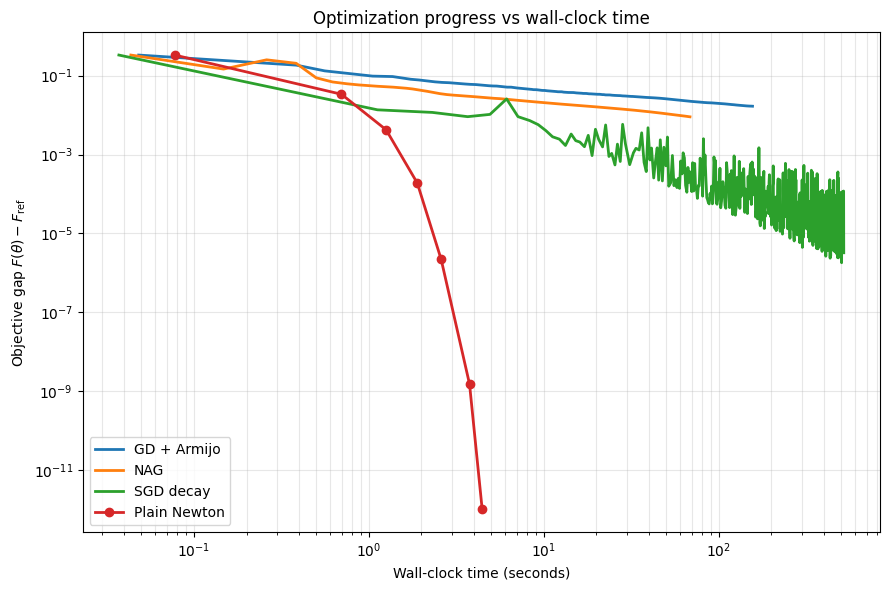

In [19]:
# ============================================================
# FINAL PLOT 1
# OBJECTIVE GAP vs WALL-CLOCK TIME
# ============================================================

# Nghiệm tham chiếu = objective cuối của Plain Newton
# Newton là optimizer tốt nhất trong main comparison.
F_ref = float(hist_newton.iloc[-1]["train_objective"])

main_histories = {
    "GD + Armijo": best_gd_hist,
    "NAG": best_nag_hist,
    "SGD decay": sgd_rep_hist,
    "Plain Newton": hist_newton,
}

plt.figure(figsize=(9, 6))

# Tránh log(0)
EPS = 1e-12
TIME_EPS = 1e-3

for name, hist in main_histories.items():

    time = np.maximum(
        hist["wall_time_seconds"].to_numpy(dtype=float),
        TIME_EPS
    )

    gap = np.maximum(
        hist["train_objective"].to_numpy(dtype=float) - F_ref,
        EPS
    )

    plt.plot(
        time,
        gap,
        marker="o" if name == "Plain Newton" else None,
        linewidth=2,
        label=name,
    )

# Cả hai trục log:
# - x log vì runtime chênh lệch rất lớn: Newton ~4s, SGD ~500s
# - y log để nhìn rõ tốc độ giảm objective gap
plt.xscale("log")
plt.yscale("log")

plt.xlabel("Wall-clock time (seconds)")
plt.ylabel(r"Objective gap $F(\theta)-F_{\mathrm{ref}}$")
plt.title("Optimization progress vs wall-clock time")

plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

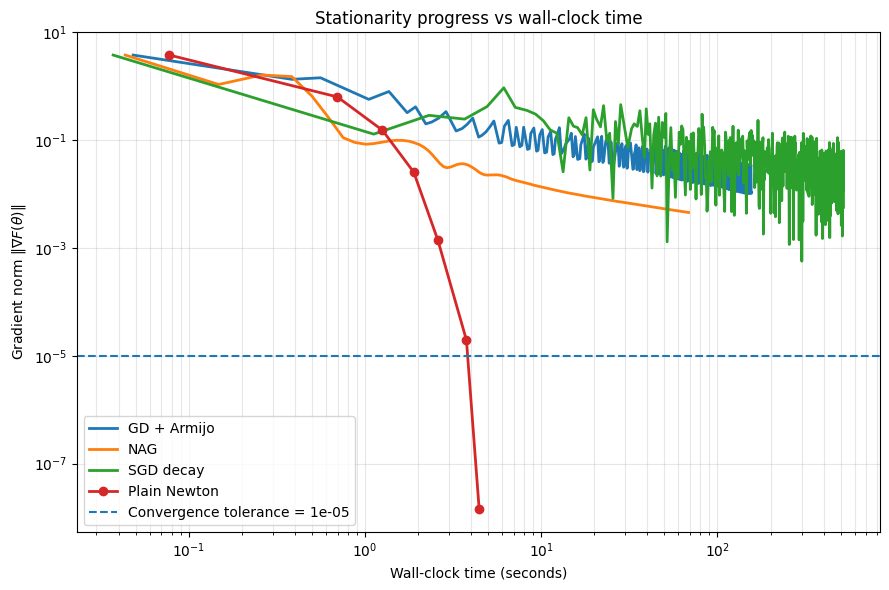

In [20]:
# ============================================================
# FINAL PLOT 2
# GRADIENT NORM vs WALL-CLOCK TIME
# ============================================================

main_histories = {
    "GD + Armijo": best_gd_hist,
    "NAG": best_nag_hist,
    "SGD decay": sgd_rep_hist,
    "Plain Newton": hist_newton,
}

plt.figure(figsize=(9, 6))

TIME_EPS = 1e-3
GRAD_EPS = 1e-15

for name, hist in main_histories.items():

    time = np.maximum(
        hist["wall_time_seconds"].to_numpy(dtype=float),
        TIME_EPS
    )

    grad_norm = np.maximum(
        hist["gradient_norm"].to_numpy(dtype=float),
        GRAD_EPS
    )

    plt.plot(
        time,
        grad_norm,
        marker="o" if name == "Plain Newton" else None,
        linewidth=2,
        label=name,
    )

# Ngưỡng hội tụ đang dùng trong notebook
plt.axhline(
    y=GRAD_TOL,
    linestyle="--",
    linewidth=1.5,
    label=rf"Convergence tolerance = {GRAD_TOL:.0e}"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Wall-clock time (seconds)")
plt.ylabel(r"Gradient norm $\|\nabla F(\theta)\|$")
plt.title("Stationarity progress vs wall-clock time")

plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()